# LangGraph from Scratch

### This is the simple workflow with graph

In [5]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai

In [7]:
def function3(input3):
  return input3

In [8]:
def function1(input1):
  return input1 + "from first function"

In [9]:
def function2(input2):
  output = function3("this is function 3 in between")
  return input2 + " " + output + " and Paryani from second function."

In [6]:
from langgraph.graph import StateGraph

In [11]:
workflow1=StateGraph(str)

In [12]:
workflow1.add_node("function1", function1)

In [13]:
workflow1.add_node("function2", function2)

In [14]:
workflow1.add_edge("function1", "function2")

In [15]:
workflow1.set_entry_point("function1")

In [16]:
workflow1.set_finish_point("function2")

In [17]:
app1=workflow1.compile()

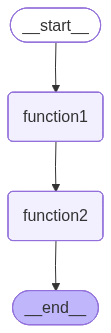

In [18]:
from IPython.display import Image, display

try:
  display(Image(app1.get_graph().draw_mermaid_png()))

except Exception as e:
  # This requires some extra dependencies and is optional
  print(e)

In [19]:
app1.invoke("Hey! This is Yousuf")

'Hey! This is Yousuffrom first function this is function 3 in between and Paryani from second function.'

In [20]:
input = "Hey! This is Yousuf"

In [21]:
for output in app1.stream(input):
  for key, value in output.items():
    print(f"Here is output from {key}")
    print("_________")
    print(value)
    print("\n")

Here is output from function1
_________
Hey! This is Yousuffrom first function


Here is output from function2
_________
Hey! This is Yousuffrom first function this is function 3 in between and Paryani from second function.




## Now lets create workflow with llm

In [22]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")

In [23]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

In [24]:
def function1(input):
  llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")
  response=llm.invoke(input).content
  return response


In [25]:
def function2(input):
  upper_case = input.upper()
  return upper_case

In [27]:
from langgraph.graph import StateGraph
workflow2=StateGraph(str)

In [28]:
workflow2.add_node("llm", function1)

In [29]:
workflow2.add_node("upper_string", function2)

In [30]:
workflow2.add_edge("llm", "upper_string")

In [31]:
workflow2.set_entry_point("llm")
workflow2.set_finish_point("upper_string")

In [32]:
app2=workflow2.compile()

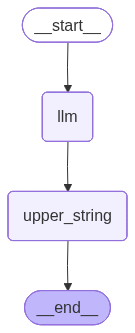

In [33]:
from IPython.display import Image, display

try:
  display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
  print(e)

In [34]:
app2.invoke("What is the name of First President of China?")

"THE FIRST PRESIDENT OF CHINA WAS DR. SUN YAT-SEN, BUT HE WAS THE PROVISIONAL PRESIDENT. \n\nTHE FIRST ELECTED PRESIDENT OF CHINA WAS YUAN SHIKAI. HE WAS THE PRESIDENT FROM 1912 TO 1915.\n\nHOWEVER, IF YOU ARE REFERRING TO THE FIRST PRESIDENT OF THE PEOPLE'S REPUBLIC OF CHINA (PRC), IT WAS MAO ZEDONG. HE WAS THE CHAIRMAN OF THE PRC FROM 1949 TO 1959. THE POSITION OF PRESIDENT WAS NOT ESTABLISHED UNTIL 1954, AND MAO ZEDONG DID NOT TAKE THE TITLE. \n\nTHE FIRST PRESIDENT OF THE PEOPLE'S REPUBLIC OF CHINA UNDER THE 1954 CONSTITUTION WAS MAO ZEDONG'S SUCCESSOR, LIU SHAOQI, WHO SERVED AS THE CHAIRMAN OF THE PRC FROM 1959 TO 1968, AND THEN THE POSITION WAS VACANT. \n\nTHE FIRST PRESIDENT OF THE PRC UNDER THE CURRENT CONSTITUTION WAS LI XIANNIAN, WHO SERVED FROM 1983 TO 1988."

In [35]:
print(app2.invoke("What is GenAI in detail?"))

GENAI, SHORT FOR GENERATIVE AI, REFERS TO A SUBSET OF ARTIFICIAL INTELLIGENCE TECHNOLOGIES THAT FOCUS ON GENERATING NEW, SYNTHETIC DATA, SUCH AS IMAGES, VIDEOS, MUSIC, TEXT, AND MORE, WHICH RESEMBLE THE DATA THEY WERE TRAINED ON. UNLIKE TRADITIONAL AI MODELS THAT ARE DESIGNED FOR ANALYSIS, CLASSIFICATION, OR PREDICTION BASED ON EXISTING DATA, GENAI MODELS ARE UNIQUE IN THEIR ABILITY TO CREATE NOVEL CONTENT.

### KEY FEATURES OF GENAI:

1. **CONTENT CREATION:** GENAI MODELS ARE CAPABLE OF GENERATING A WIDE RANGE OF DATA TYPES, INCLUDING BUT NOT LIMITED TO TEXT, IMAGES, AUDIO, VIDEO, AND 3D MODELS. THIS CAPABILITY HAS NUMEROUS APPLICATIONS ACROSS CREATIVE INDUSTRIES, TECHNOLOGY, AND RESEARCH.

2. **LEARNING FROM DATA:** THESE MODELS ARE TRAINED ON LARGE DATASETS, LEARNING PATTERNS, STRUCTURES, AND FEATURES FROM THE DATA. THE QUALITY AND DIVERSITY OF THE TRAINING DATA SIGNIFICANTLY INFLUENCE THE OUTPUT OF GENAI MODELS.

3. **GENERATIVE MODELS:** THE CORE OF GENAI CONSISTS OF GENERATIVE MO

In [36]:
input = "What is the name of the First President of China?"

In [37]:
for output in app2.stream(input):
  for key, value in output.items():
    print(f"Here is output from {key}")
    print("___________")
    print(value)
    print("\n")

Here is output from llm
___________
The first president of China was actually Dr. Sun Yat-sen, who served as the Provisional President of the Republic of China from January 1, 1912, to March 25, 1912. However, he was not the first president of the People's Republic of China (PRC), which was established in 1949.

If you are referring to the PRC, the first president was Mao Zedong, who served as the Chairman of the Central People's Government from 1949 to 1959, and then as the Chairman of the People's Republic of China from 1959 to 1976.

It's worth noting that the title of "President" was not used in China until the Republic of China was established in 1912. Prior to that, China was ruled by emperors, and later by the Beiyang government and the Nationalist government.


Here is output from upper_string
___________
THE FIRST PRESIDENT OF CHINA WAS ACTUALLY DR. SUN YAT-SEN, WHO SERVED AS THE PROVISIONAL PRESIDENT OF THE REPUBLIC OF CHINA FROM JANUARY 1, 1912, TO MARCH 25, 1912. HOWEVER, H

Here lets create our own output token counter



In [38]:
def function3(input):
  token=input.split()
  token_number=len(token)
  token_number = f"total token number is {token_number}"
  return token_number

In [40]:
workflow3=StateGraph(str)
workflow3.add_node("llm", function1)
workflow3.add_node("token_counter", function3)
workflow3.add_edge("llm", "token_counter")
workflow3.set_entry_point("llm")
workflow3.set_finish_point("token_counter")
app3=workflow3.compile()

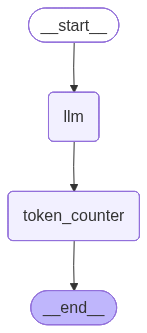

In [41]:
from IPython.display import Image, display

try:
  display(Image(app3.get_graph().draw_mermaid_png()))
except Exception as e:
  print(e)

In [42]:
app3.invoke("What is the name of First President of China?")

'total token number is 164'

In [43]:
app3.invoke("What is GenAI in detail?")

'total token number is 531'

### Question: Can we integrate a RAG Pipeline?

### Answer: yes we can!



In [44]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [45]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

In [46]:
llm.invoke("hi")

AIMessage(content='Hi! How are you doing today? Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 11, 'total_tokens': 35, 'completion_time': 0.054281392, 'completion_tokens_details': None, 'prompt_time': 0.000362845, 'prompt_tokens_details': None, 'queue_time': 0.845952055, 'total_time': 0.054644237}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f08cd12a81', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e516e-e675-7f30-8e34-951a9e268673-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 24, 'total_tokens': 35})

In [47]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

/tmp/ipykernel_11629/3696339677.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader, DirectoryLoader


In [49]:
loader=DirectoryLoader("data", glob="./*.txt", loader_cls=TextLoader)
docs = loader.load()
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50,
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [50]:
db = Chroma.from_documents(new_docs, embeddings)

retriever = db.as_retriever(search_kwargs={"k": 3})

In [53]:
query = "What is Meta LLama3?"
docs = retriever.invoke(query)

print(docs[0].metadata)
print(docs[1].page_content)

for doc in docs:
  print(doc)

{'source': 'data/llama3.txt'}
services use a Llama 3 model.[12] Reception was mixed, with some users confused after Meta AI told
page_content='by Meta AI starting in February 2023.[2][3] The latest version is Llama 3 released in April' metadata={'source': 'data/llama3.txt'}
page_content='services use a Llama 3 model.[12] Reception was mixed, with some users confused after Meta AI told' metadata={'source': 'data/llama3.txt'}
page_content='available as a foundation model.[8] Starting with Llama 2, Meta AI started releasing instruction' metadata={'source': 'data/llama3.txt'}


In [54]:
def function_1(AgentState):

  message=AgentState["messages"]

  question=message[-1]

  complete_prompt = "Your task is to provide only the brief answer based on the user query. \
        Don't include too much reasoning. Following is the user query: " + question

  response = llm.invoke(complete_prompt)

  AgentState["messages"].append(response.content) # appending LLM call response to the AgentState

  # pront(AgentState)

  return AgentState




In [55]:
AgentState={}

In [56]:
AgentState["messages"]=[]

In [57]:
AgentState

{'messages': []}

In [58]:
AgentState["messages"].append("Hey! How are ya?")

In [59]:
AgentState

{'messages': ['Hey! How are ya?']}

In [60]:
AgentState["messages"].append("Hey! How are ya doing?")

In [61]:
AgentState

{'messages': ['Hey! How are ya?', 'Hey! How are ya doing?']}

In [134]:
def function_2(AgentState):
  messages = AgentState["messages"]
  question = messages[0] ## Fetching the user question

  template = """Answer the question based only on the following context:
  {context}

  Question: {question}
  """
  prompt = ChatPromptTemplate.from_template(template)

  retrieval_chain = (
      {"context": retriever, "question": RunnablePassthrough()}
      | prompt
      | llm
      | StrOutputParser()
  )

  result = retrieval_chain.invoke(question)
  return result

In [136]:
# Define a LangChain Graph

from langgraph.graph import StateGraph

workflow4 = StateGraph(str)
workflow4.add_node("llm", function_1)
workflow4.add_node("RAGtool", function_2)
workflow4.add_edge("llm", "RAGtool")
workflow4.set_entry_point("llm")
workflow4.set_finish_point("RAGtool")
app4=workflow4.compile()

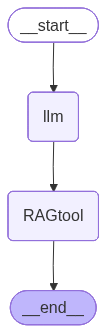

In [137]:
from IPython.display import Image, display

try:
    display(Image(app4.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [138]:
inputs = {"messages": ["What is llama3 model?"]}

In [139]:
for output in app4.stream(inputs):
  # Stream() yields dictionary with output keyed by node name
  for key, value in output.items():
    print(f"Output from node '{key}':")
    print("---")
    print(value)
  print("\n---\n")

What is llama3 model?
Topic='Not Related' Reasoning='The user query is asking about the llama3 model, which does not appear to be related to India.'
Output from node 'llm':
---
{'messages': ['Not Related']}

---

-> Calling RAG ->
Not Related
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]
Output from node 'RAGtool':
---
{'messages': ['There is no question related to the provided context. The instruction is to answer based on the context, but the question "Not Related" does not relate to the context. \n\nHowever, if I had to provide a response based on the lack of a relevant question, I would say: \n\nNo answer can be provided as the question does not relate to the given context.']}


In [140]:
loader2 = DirectoryLoader("data", glob="./*.txt", loader_cls=TextLoader)
docs2 = loader2.load()

text_splitter2 = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50,
)

new_docs2 = text_splitter2.split_documents(documents=docs2)
doc_strings2 = [doc.page_content for doc in new_docs2]

In [141]:
db2 = Chroma.from_documents(new_docs2, embeddings)
retriever2 = db2.as_retriever(search_kwargs={"k": 3})

In [142]:
query = "Explain about India's Industrial Growth."
docs = retriever2.invoke(query)
print(docs[0].metadata)
print(docs[0].page_content)

for doc in docs:
  print(doc)

{'source': 'data/indian_economy.txt'}
India’s industrial growth has outpaced expectations, raising hopes that the economy will avoid a
page_content='India’s industrial growth has outpaced expectations, raising hopes that the economy will avoid a' metadata={'source': 'data/indian_economy.txt'}
page_content='India’s industrial growth has outpaced expectations, raising hopes that the economy will avoid a' metadata={'source': 'data/indian_economy.txt'}
page_content='Industrial Revival and Economic Optimism for India' metadata={'source': 'data/indian_economy.txt'}


1. TypedDict:
- TypedDict is a special type that allows you to define a dictionary in python programming where each key has a specific type.
It’s useful when you want to enforce type checks on the keys and values of a dictionary.

2. Annotated:
- Annotated is used to add metadata or constraints to a type.
It’s typically used for adding additional information, like constraints or descriptions, to the type.

3. Sequence[BaseMessage]:
- Sequence is a generic type from python programming typing module that represents a list-like structure (such as a list or tuple) where the order matters, and you can access elements by their position.

4. BaseMessage:
- Basemessage: This assumes you're working with the LangChain framework, and BaseMessage is part of its core messaging system. It is typically used when handling or processing messages in LangChain's workflows

5. operator.add:

- operator.add is a function from python programming operator module that performs addition (+) on its arguments.
In this context, operator.add is being used as metadata for the Annotated type, likely suggesting that the sequence of BaseMessage objects is meant to be "added" or concatenated with another sequence at some point. It’s an indicator of how the messages field will be treated in the logic of your program.


- **TopicSelectionParser:** A Pydantic model that defines two fields (Topic and Reasoning), both of which are required to be strings.
- **Field:** Adds metadata, like descriptions, and can also be used for validation and constraints.
- **Pydantic’s Role:** Ensures that the data matches the expected structure and types, raising validation errors if the data is invalid.

In [143]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_classic.prompts import PromptTemplate
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import PydanticOutputParser

In [144]:
class AgentState(TypedDict):
  # The 'messages' field should be a sequence of strings, and we annotate it with 'operator.add'
  # This implies we might want to "add" new messages to the sequence later
  messages: Annotated[Sequence[BaseMessage], operator.add]

### Putting It All Together:

- The line messages: Annotated[Sequence[BaseMessage], operator.add] defines a field messages that:

- Must be a sequence (like a list or tuple) of BaseMessage objects.
Has the additional annotation operator.add, which suggests that this sequence is intended to support addition (i.e., concatenation of multiple sequences of messages).

messages: Annotated[Sequence[BaseMessage], operator.add]

"messages": [BaseMessage("Hello!", "Alice"), BaseMessage("Hi!", "Bob")]

In [145]:
from pydantic import BaseModel, Field
class TopicSelectionParser(BaseModel):
  Topic: str = Field(description='Selected Topic')
  Reasoning: str = Field(description='Reasoning for selecting the topic')

In [146]:
from langchain_classic.output_parsers import PydanticOutputParser
parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [147]:
print(parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning for selecting the topic", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
```


In [148]:
def function_1(state):
  message=state["messages"]
  question=message[-1]
  print(question)

  template="""
      Your task is to classify the given user query into one of the following categories: [India, Not Related].
        Only respond with the category name and nothing else.

        User query: {question}
        {format_instructions}
      """

  prompt = PromptTemplate(template=template, input_variables=[question], partial_variables={
       "format_instructions": parser.get_format_instructions()
   })

  chain = prompt | llm | parser

  response = chain.invoke({'question': question, "format_instructions": parser.get_format_instructions()})

  print(response)

  return {"messages": [response.Topic]}

In [149]:
template="""
    Your task is to classify the given user query into one of the following categories: [India, Not Related].
    Only respond with the category name and nothing else.

    User query: "Tell me about India's Industrial Growth"
    The output should be formatted as a JSON instance that conforms to the JSON schema below.

    As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
    the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

    Here is the output schema:
    ```
    {"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
        """

template="""
    Your task is to classify the given user query into one of the following categories: [India, Not Related].
    Only respond with the category name and nothing else.

    User query: "Tell me about India's Industrial Growth"
    The output should be formatted as a JSON instance that conforms to the JSON schema below.

    As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
    the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

    Here is the output schema:
    ```
    {"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
        """

In [150]:
state = {"messages": "What is India's Industrial Growth?" }

In [151]:
function_1(state)

?
Topic='India' Reasoning='The query directly pertains to India, asking for its capital.'


{'messages': ['India']}

In [152]:
def router(state):
  print('-> Router ->')

  messages = state["messages"]
  last_message = messages[-1]
  print(last_message)
  if 'India' in last_message:
    return 'RAG Call'
  else:
    return 'LLM Call'

In [153]:
def function_2(state):
  print('-> Calling RAG ->')
  messages = state['messages']
  question = messages[0] ## Fetching the user question
  print(question)

  template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
  prompt = ChatPromptTemplate.from_template(template)

  print(prompt)

  retrieval_chain = (
      {'context': retriever, "question": RunnablePassthrough()}
      | prompt
      | llm
      | StrOutputParser()
  )

  result = retrieval_chain.invoke(question)
  return {"messages": [result]}

In [154]:
def function_3(state):
  print('-> Calling LLM ->')

  messages = state['messages']
  question = messages[0] ## Fetching the user question

  # Normal LLM Call
  complete_query = "Anwer the follow question with your knowledge of the real world. Following is the user question: " + question
  response = llm.invoke(complete_query)
  return {"messages": [response.content]}

In [155]:
AgentState

__main__.AgentState

In [156]:
from langgraph.graph import StateGraph, END

workflow5 = StateGraph(AgentState) ### StateGraph with AgentState

workflow5.add_node("agent", function_1)

workflow5.add_node("RAG", function_2)

workflow5.add_node("LLM", function_3)

workflow5.set_entry_point("agent")

workflow5.add_conditional_edges(
    "agent",

    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM"
    }
)


workflow5.add_edge("RAG", END)

workflow5.add_edge("LLM", END)

app5 = workflow5.compile()

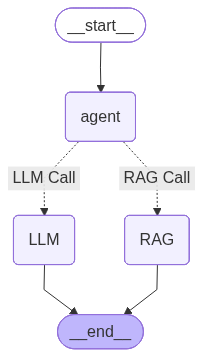

In [157]:
from IPython.display import Image, display

try:
    display(Image(app5.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [158]:
inputs = {"messages": ["What is India's Industrial Growth?"]}

In [159]:
output = app5.invoke(inputs)

What is India's Industrial Growth?
Topic='India' Reasoning="The user query is directly related to India, specifically asking about India's Industrial Growth."
-> Router ->
India
-> Calling RAG ->
What is India's Industrial Growth?
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


In [160]:
output

{'messages': ["What is India's Industrial Growth?",
  'India',
  "India's industrial growth has outpaced expectations."]}

In [161]:
inputs = {"messages": ["Tell me about Meerut City?"]}

In [162]:
output = app5.invoke(inputs)

Tell me about Meerut City?
Topic='India' Reasoning='The query is about Meerut City, which is a city in the state of Uttar Pradesh, India.'
-> Router ->
India
-> Calling RAG ->
Tell me about Meerut City?
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


In [163]:
inputs = {"messages": ["who build the Taj Mahal?"]}

In [164]:
output = app5.invoke(inputs)

who build the Taj Mahal?
Topic='India' Reasoning='The Taj Mahal is a famous monument located in India, and the query is asking about its builder, which is related to Indian history and culture.'
-> Router ->
India
-> Calling RAG ->
who build the Taj Mahal?
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


In [165]:
output

{'messages': ['who build the Taj Mahal?',
  'India',
  'There is no information provided in the context to answer the question about who built the Taj Mahal. The context only discusses the Indian economy and does not mention the Taj Mahal or its builder.']}

In [166]:
inputs = {"messages": ["who is a president of USA?"]}

In [167]:
output = app5.invoke(inputs)

who is a president of USA?
Topic='Not Related' Reasoning='The query is about the president of the USA, which is not related to India.'
-> Router ->
Not Related
-> Calling LLM ->


In [168]:
output

{'messages': ['who is a president of USA?',
  'Not Related',
  "As of my knowledge cutoff in 2023, the President of the United States is Joe Biden. He was inaugurated as the 46th President of the United States on January 20, 2021. \n\nHowever, please note that my knowledge may not be up-to-date, and it's always best to verify with a reliable news source for the most current information. \n\nIf you'd like to know more about Joe Biden or any other President of the United States, I'd be happy to help!"]}

In [169]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [170]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct")

In [176]:
import json
from typing import Union
#from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langchain_core.utils.function_calling import convert_to_openai_tool

In [177]:
@tool
def multiply(first_number: Union[int, str], second_number: Union[int, str]):
  """Multiplies two number together"""
  try:
    num1 = int(first_number)
    num2 = int(second_number)
    return num1 * num2
  except ValueError:
    return "Error: Non-numeric input provided to multiply tool."

In [178]:
tools = [convert_to_openai_tool(multiply)]

In [179]:
model_with_tools = llm.bind(tools=tools)

In [180]:
response = model_with_tools.invoke('What is 35 * 46?')

In [181]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qwbkgmy1e', 'function': {'arguments': '{"first_number":"35","second_number":"46"}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 740, 'total_tokens': 777, 'completion_time': 0.083572698, 'completion_tokens_details': None, 'prompt_time': 0.036997786, 'prompt_tokens_details': None, 'queue_time': 0.269172329, 'total_time': 0.120570484}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e518b-a232-7921-9d5e-c9a30c01b662-0', tool_calls=[{'name': 'multiply', 'args': {'first_number': '35', 'second_number': '46'}, 'id': 'qwbkgmy1e', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 740, 'output_tokens': 37, 'total_tokens': 777})

In [182]:
tool_calls = response.additional_kwargs.get('tool_calls')

In [183]:
tool_calls

[{'id': 'qwbkgmy1e',
  'function': {'arguments': '{"first_number":"35","second_number":"46"}',
   'name': 'multiply'},
  'type': 'function'}]

In [184]:
for tool_call in tool_calls:
  print('Function Name:',tool_call.get('function').get('name'))
  print('Function Arguments:',tool_call.get('function').get('arguments'))
  print(tool_call)

Function Name: multiply
Function Arguments: {"first_number":"35","second_number":"46"}
{'id': 'qwbkgmy1e', 'function': {'arguments': '{"first_number":"35","second_number":"46"}', 'name': 'multiply'}, 'type': 'function'}


In [185]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage

In [186]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], operator.add]

In [187]:
def invoke_model(state):
  messages = state['messages']
  question = messages[-1] ## Fetching the user question
  return {"messages": [model_with_tools.invoke(question)]}

In [188]:
input = {"messages": ["how much is 30 * 35?"]}

In [189]:
invoke_model(input)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4vmevzz6z', 'function': {'arguments': '{"first_number":"30","second_number":"35"}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 741, 'total_tokens': 778, 'completion_time': 0.083720257, 'completion_tokens_details': None, 'prompt_time': 0.037811303, 'prompt_tokens_details': None, 'queue_time': 0.644541869, 'total_time': 0.12153156}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f0bb21cb36', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e518c-b991-7140-94b4-46f990e9282c-0', tool_calls=[{'name': 'multiply', 'args': {'first_number': '30', 'second_number': '35'}, 'id': '4vmevzz6z', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 741, 'output_tokens': 37, 'total_tokens': 778})]}

In [192]:
def invoke_tool(state):
  tool_calls = state['messages'][-1].additional_kwargs.get("tool_calls", [])
  print(f"here is a tool_calls {tool_calls}")
  multiply_call = True

  for tool_call in tool_calls:
    if tool_call.get("function").get("name") == "multiply":
      multiply_call = tool_call

  if multiply_call is None:
    raise Exception("No adder input found.")

  res = multiply.invoke(
      json.loads(multiply_call.get("function").get("arguments"))
  )

  return {"messages": [res]}

In [193]:
def router(state):
  tool_calls = state["messages"][-1].additional_kwargs.get("tool_calls", [])
  if len(tool_calls):
    return "multiply"
  else:
    return "end"

In [194]:
from langgraph.graph import StateGraph, END
workflow6 = StateGraph(AgentState)
workflow6.add_node("agent", invoke_model)
workflow6.add_node("tool", invoke_tool)

In [195]:
workflow6.set_entry_point("agent")
workflow6.add_conditional_edges("agent", router, {"multiply":"tool", "end": END})
workflow6.add_edge("tool", END)
app6 = workflow6.compile()

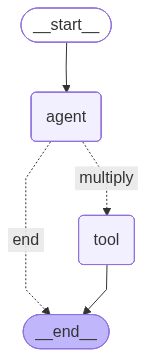

In [196]:
from IPython.display import Image, display

try:
    display(Image(app6.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [197]:
app6.invoke({"messages": ["What is LLM?"]})

{'messages': ['What is LLM?',
  AIMessage(content="LLM stands for Large Language Model. It's a type of artificial intelligence (AI) model designed to process and understand human language. LLMs are trained on vast amounts of text data, which enables them to generate human-like responses, translate languages, summarize content, and even create text. They're a key area of research in natural language processing (NLP) and have many applications, including chatbots, language translation, and text generation.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 736, 'total_tokens': 823, 'completion_time': 0.196809262, 'completion_tokens_details': None, 'prompt_time': 0.028051227, 'prompt_tokens_details': None, 'queue_time': 0.502570947, 'total_time': 0.224860489}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f0bb21cb36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provi

In [198]:
app6.invoke({"messages": ["What is 123 * 456?"]})

here is a tool_calls [{'id': 'kavjqqm14', 'function': {'arguments': '{"first_number":"123","second_number":"456"}', 'name': 'multiply'}, 'type': 'function'}]


{'messages': ['What is 123 * 456?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'kavjqqm14', 'function': {'arguments': '{"first_number":"123","second_number":"456"}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 740, 'total_tokens': 777, 'completion_time': 0.083862036, 'completion_tokens_details': None, 'prompt_time': 0.029653019, 'prompt_tokens_details': None, 'queue_time': 0.691173755, 'total_time': 0.113515055}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_4221711889', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e518e-fd8b-7893-9773-92aacda8a02a-0', tool_calls=[{'name': 'multiply', 'args': {'first_number': '123', 'second_number': '456'}, 'id': 'kavjqqm14', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 740, 'output_tokens': 37, 'total_tokens':

In [199]:
for output in app6.stream({"messages": ["What is 123 * 456?"]}):
  for key, value in output.items():
    print(f"here is output from {key}")
    print("_______")
    print(value)
    print("\n")

here is output from agent
_______
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dd89pjynx', 'function': {'arguments': '{"first_number":"123","second_number":"456"}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 740, 'total_tokens': 777, 'completion_time': 0.083850047, 'completion_tokens_details': None, 'prompt_time': 0.029567739, 'prompt_tokens_details': None, 'queue_time': 0.615632693, 'total_time': 0.113417786}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_4221711889', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e518f-07a0-7690-be41-9200d39f7a06-0', tool_calls=[{'name': 'multiply', 'args': {'first_number': '123', 'second_number': '456'}, 'id': 'dd89pjynx', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 740, 'output_tokens': 37, 'tota